In [1]:
import numpy as np
import pylab as plt
import pyccl as ccl
import math
from typing import NamedTuple
#from collections import namedtuple

# plots are rendered inline within the notebook
%matplotlib inline 

# Set global plt font to LaTex like font (or any installed system font)
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

In [3]:
def update_cosmo_params(cosmology: dict, m_v: float) -> dict:
    """
    Updates cosmology parameters due to effects of non-zero neutrino mass, keping the
    Sound Horizon, matter-radiation equality and baryon-to-photon ratio at recombination constant.
    Based on 'Massive neutrinos and cosmic composition' (2024, https://arxiv.org/abs/2410.00090) by Marilena Loverde, Zachary J. Weiner

    Args:
        cosmology (dict): includes values for Omega_m, Omega_b, h, A_s, n_s, w0, wa.
        m_v (float): sum of 3 neutrino mass species in eV.

    Returns:
        updated_cosmology(dict): includes the old parameters, adds the sum of the neutrino mass as a new dict value 
                                 and updates the values of Omega_m and h.
    """
    updated_cosmology = cosmology
    #w_v = m_v/93.14
    
    f_v = (m_v/13.2)*((cosmology["Omega_m"]*cosmology["h"]**2)/0.142)**(-1)

    updated_cosmology["Omega_m"] = cosmology["Omega_m"]*(1. + f_v)**5.32
    updated_cosmology["h"] = cosmology["h"]/(1. + f_v)**2.16 #REVISE: not right formula? w_r??

    #updated_cosmology["m_v"] = m_v #optional

    return updated_cosmology

In [26]:
def update_cosmo_params2(cosmology: dict, w_v: float, f_v: float) -> dict:
    """
    Updates cosmology parameters due to effects of non-zero neutrino mass, keping the
    Sound Horizon, matter-radiation equality and baryon-to-photon ratio at recombination constant.
    Based on 'Massive neutrinos and cosmic composition' (2024, https://arxiv.org/abs/2410.00090) by Marilena Loverde, Zachary J. Weiner.
    Computes neutrino mass sum from its physicall density

    Args:
        cosmology (dict): includes values for Omega_m, Omega_b, h, A_s, n_s, w0, wa.
        w_v (float): physicall neutrino density (Omega_v*h^2)
        f_v (float): fraction of neutrino density over matter density
    Returns:
        updated_cosmology(dict): includes the old parameters, adds the sum of the neutrino mass as a new dict value 
                                 and updates the values of Omega_m and h.
    """
    updated_cosmology = cosmology

    updated_cosmology["Omega_m"] = cosmology["Omega_m"]*(1. + f_v)**5.32
    updated_cosmology["h"] = cosmology["h"]/(1. + f_v)**2.16 #REVISE: not right formula? w_r??

    m_v = 93.14*w_v #neutrino mass in eV
    updated_cosmology["m_v"] = m_v 

    return updated_cosmology

In [27]:
def update_cosmo_params3(cosmology: dict, m_v: float) -> dict:
    """
    Updates cosmology parameters due to effects of non-zero neutrino mass, keping ......(need to finish)
    Based on (2016, https://arxiv.org/abs/1610.09852) by Maria Archidiacono et al.

    Args:
        cosmology (dict): includes values for Omega_m, Omega_b, h, A_s, n_s, w0, wa.
        m_v (float): sum of 3 neutrino mass species in eV.

    Returns:
        updated_cosmology(dict): includes the old parameters, adds the sum of the neutrino mass as a new dict value 
                                 and updates the values of Omega_m and h.
    """
    updated_cosmology = cosmology
    #w_v = m_v/93.14
    updated_cosmology["h"] = cosmology["h"] - 0.09*m_v

    updated_cosmology["Omega_m"] = cosmology["Omega_m"] + m_v/(93.14*updated_cosmology["h"]**2)
    
    return updated_cosmology

In [5]:
cosmology = {"Omega_m": 0.315, "Omega_b": 0.049, "h": 0.674, "A_s": 2.0989e-9, "n_s": 0.965, "w0": -1," wa": 0}
cosmologies_1 = [] 
m_nu_list = [0., 0.06, 0.09, 0.12]

## -m_v/(93.14*new_cosmology["h"]**2) --> - Omega_v

for m_v in m_nu_list:
    new_cosmology = update_cosmo_params(cosmology, m_v)
    #new_cosmology = cosmology
    cosmo = ccl.Cosmology(Omega_c=new_cosmology['Omega_m']-new_cosmology['Omega_b']-m_v/(93.14*new_cosmology["h"]**2), Omega_b=new_cosmology["Omega_b"], h=new_cosmology["h"], 
                          A_s=new_cosmology["A_s"], n_s=new_cosmology["n_s"], m_nu=m_v, 
                          mass_split='equal', matter_power_spectrum="camb") # A_s when changing parameters
    cosmologies_1.append(cosmo)
print(cosmologies_1)


[<pyccl.cosmology.Cosmology>
	A_s        = 2.0989e-09
	Neff       = 3.044
	Omega_b    = 0.049
	Omega_c    = 0.266
	h          = 0.674
	mass_split = equal
	n_s        = 0.965
	matter_power_spectrum = camb
	extra_parameters =
	HASH_ACCURACY_PARAMS = 0x995af5b13355bb02, <pyccl.cosmology.Cosmology>
	A_s        = 2.0989e-09
	Neff       = 3.044
	Omega_b    = 0.049
	Omega_c    = 0.2721869932865223
	h          = 0.6674797814514547
	m_nu       = 0.06
	mass_split = equal
	n_s        = 0.965
	matter_power_spectrum = camb
	extra_parameters =
	HASH_ACCURACY_PARAMS = 0x995af5b13355bb02, <pyccl.cosmology.Cosmology>
	A_s        = 2.0989e-09
	Neff       = 3.044
	Omega_b    = 0.049
	Omega_c    = 0.2831305986068738
	h          = 0.6578711712843068
	m_nu       = 0.09
	mass_split = equal
	n_s        = 0.965
	matter_power_spectrum = camb
	extra_parameters =
	HASH_ACCURACY_PARAMS = 0x995af5b13355bb02, <pyccl.cosmology.Cosmology>
	A_s        = 2.0989e-09
	Neff       = 3.044
	Omega_b    = 0.049
	Omega_c    = 0

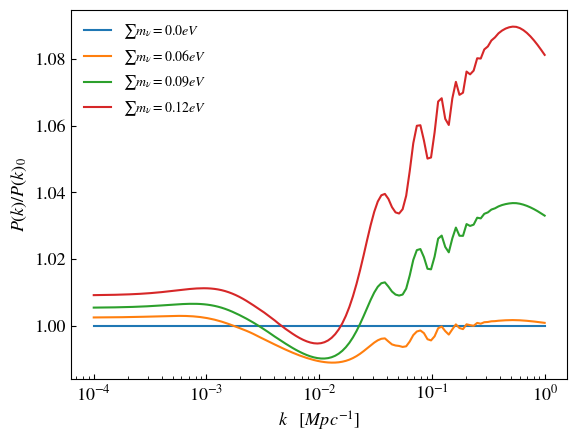

In [5]:
# ----------------------------- Plotting

kmin, kmax, nk = 1e-4, 1e0, 128 #nk = number of evenly spaced points in array
k = np.logspace(np.log10(kmin), np.log10(kmax), nk) # Wavenumber
a = 1. # Scale factor a z=0 --> present

power_spectras_1 = [] #list to store power spectras

for cosmo_i in cosmologies_1:
    pk = ccl.nonlin_matter_power(cosmo_i, k, a)
    power_spectras_1.append(pk)

# ---------------------------

for pk,m in zip(power_spectras_1,m_nu_list):
    plt.semilogx(k, pk/power_spectras_1[0], label = r"$\sum m_{{\nu}} = {} eV$".format(m))

plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('$k\\quad[Mpc^{-1}]$', fontsize = 13)
plt.ylabel('$P(k)/P(k)_0$', fontsize = 13)

plt.gca().tick_params(axis = 'both', which = 'both', direction = 'in', top = False, bottom = True, left = True, right = False)
plt.legend(fontsize = 10, frameon = False)

plt.show()

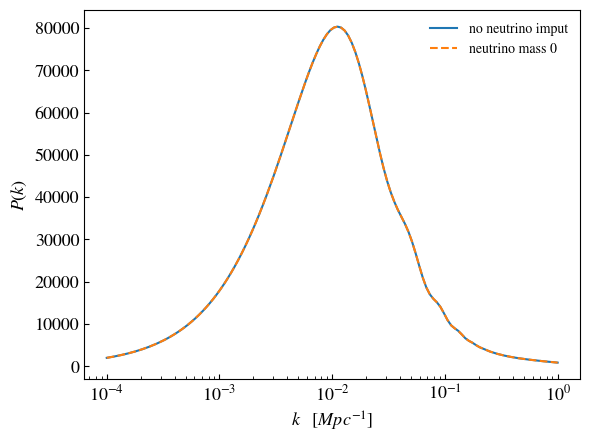

In [38]:
# Is it the same to do a cosmology wo neutrinos and with neutrino mass = 0?

cosmology = {"Omega_m": 0.315, "Omega_b": 0.049, "h": 0.674, "A_s": 2.0989e-9, "n_s": 0.965, "w0": -1," wa": 0}

cosmo1 = ccl.Cosmology(Omega_c=cosmology['Omega_m']-cosmology['Omega_b'], Omega_b=cosmology["Omega_b"], h=cosmology["h"], 
                          A_s=cosmology["A_s"], n_s=cosmology["n_s"],matter_power_spectrum="camb")
cosmo2 = ccl.Cosmology(Omega_c=cosmology['Omega_m']-cosmology['Omega_b'], Omega_b=cosmology["Omega_b"], h=cosmology["h"], 
                          A_s=cosmology["A_s"], n_s=cosmology["n_s"], m_nu=0., 
                          mass_split='equal', matter_power_spectrum="camb")

kmin, kmax, nk = 1e-4, 1e0, 128 #nk = number of evenly spaced points in array
k = np.logspace(np.log10(kmin), np.log10(kmax), nk) # Wavenumber
a = 1. # Scale factor a z=0 --> present

pk1 = ccl.nonlin_matter_power(cosmo1, k, a)
pk2 = ccl.nonlin_matter_power(cosmo2, k, a)

plt.semilogx(k, pk1, label = r"no neutrino imput")
plt.semilogx(k, pk2, label = r"neutrino mass 0", linestyle='--')

plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.xlabel('$k\\quad[Mpc^{-1}]$', fontsize = 13)
plt.ylabel('$P(k)$', fontsize = 13)

plt.gca().tick_params(axis = 'both', which = 'both', direction = 'in', top = False, bottom = True, left = True, right = False)
plt.legend(fontsize = 10, frameon = False)

plt.show()




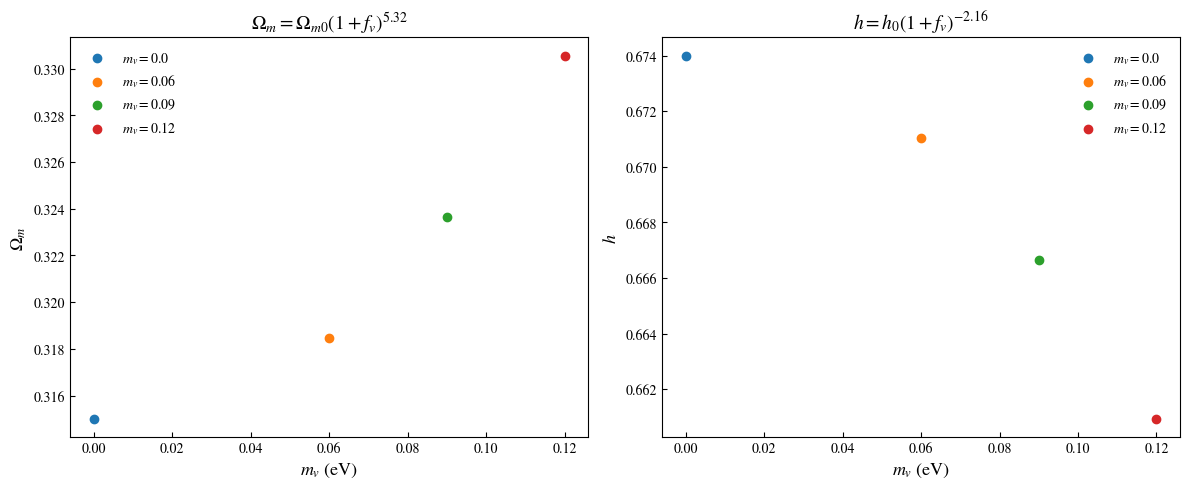

In [51]:
# ----------------------------- Plotting
cosmology = {"Omega_m": 0.315, "Omega_b": 0.049, "h": 0.674, "A_s": 2.0989e-9, "n_s": 0.965, "w0": -1, "wa": 0}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

for m_v in m_nu_list:
    new_cosmology = update_cosmo_params(cosmology, m_v)
    
    # Left plot: Omega_m vs. m_v
    axes[0].scatter(m_v, new_cosmology['Omega_m'], label=rf"$m_v = {m_v}$")

    # Right plot: h vs. m_v
    axes[1].scatter(m_v, new_cosmology['h'], label=rf"$m_v = {m_v}$")

# Customize left plot
axes[0].set_xlabel(r'$m_v$ (eV)', fontsize=13)
axes[0].set_ylabel(r'$\Omega_m$', fontsize=13)
axes[0].tick_params(axis='both', which='both', direction='in', top=False, bottom=True, left=True, right=False)
axes[0].legend(fontsize=10, frameon=False)
axes[0].set_title(r'$\Omega_m = \Omega_{m0} (1+f_v)^{5.32}$', fontsize=14)

# Customize right plot
axes[1].set_xlabel(r'$m_v$ (eV)', fontsize=13)
axes[1].set_ylabel(r'$h$', fontsize=13)
axes[1].tick_params(axis='both', which='both', direction='in', top=False, bottom=True, left=True, right=False)
axes[1].legend(fontsize=10, frameon=False)
axes[1].set_title(r'$h = h_0 (1+f_v)^{-2.16}$', fontsize=14)


plt.tight_layout()
plt.show()


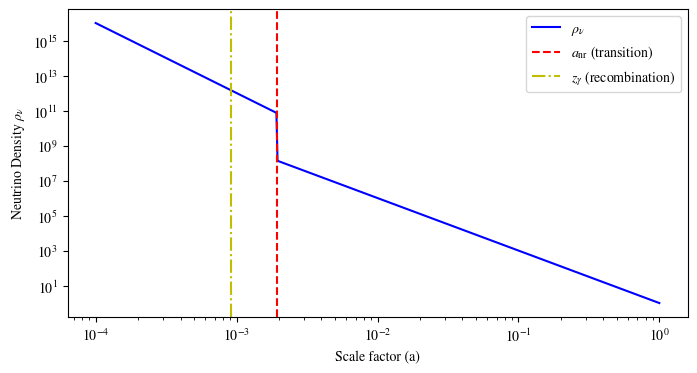

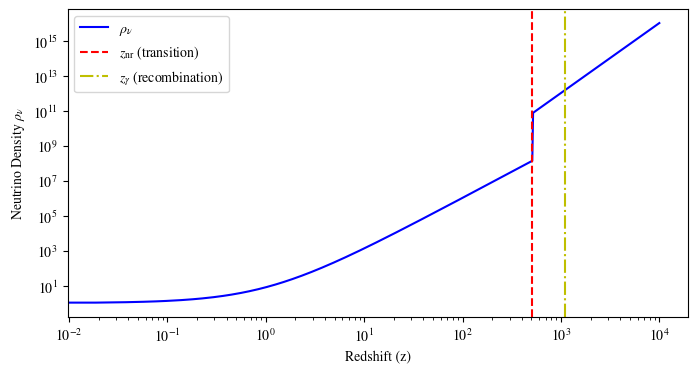

In [3]:
# neutrino density evolution

def plot_neutrino_density(m_nu=0.1):
    """
    Plots the evolution of neutrino density as a function of scale factor and redshift.
    The transition from radiation-like to matter-like behavior is marked.
    
    Parameters:
    m_nu : float
        Neutrino mass in eV (default is 0.1 eV).
    """
    # Constants
    T_nu0 = 1.95e-4  # Present-day neutrino temperature in eV
    a_eq = T_nu0 / m_nu  # Scale factor when neutrinos become non-relativistic

    # Define scale factor and redshift ranges
    a = np.logspace(-4, 0, 500)  # Logarithmic scale for better visibility
    z = 1/a - 1.  # Convert to redshift

    # Neutrino density evolution
    rho_nu_rel = a**-4  # Radiation-like scaling
    rho_nu_nonrel = a**-3  # Matter-like scaling
    
    # Transition from relativistic to nonrelativistic
    rho_nu = np.where(a < a_eq, rho_nu_rel, rho_nu_nonrel)

    # Plot 1: Neutrino density vs. scale factor
    plt.figure(figsize=(8, 4))
    plt.plot(a, rho_nu, label=r'$\rho_\nu$', color='b')
    plt.axvline(a_eq, color='r', linestyle='--', label=r'$a_{\rm nr}$ (transition)')
    plt.axvline(1/1101, color='y', linestyle='-.', label=r'$z_{\gamma}$ (recombination)')
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Scale factor (a)")
    plt.ylabel(r"Neutrino Density $\rho_\nu$")
    plt.legend()
    #plt.grid(True)
    
    # Plot 2: Neutrino density vs. redshift
    plt.figure(figsize=(8, 4))
    plt.plot(z, rho_nu, label=r'$\rho_\nu$', color='b')
    plt.axvline(1/a_eq - 1., color='r', linestyle='--', label=r'$z_{\rm nr}$ (transition)')
    plt.axvline(1100, color='y', linestyle='-.', label=r'$z_{\gamma}$ (recombination)')
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Redshift (z)")
    plt.ylabel(r"Neutrino Density $\rho_\nu$")
    plt.legend()
    #plt.grid(True)
    
    plt.show()

plot_neutrino_density(m_nu=0.1)


In [12]:
import numpy as np

tracer_combinations = ['z0-z0', 'z0-z1', 'z0-z2', 'z0-z3', 'z0-z4', 'z1-z1', 'z1-z2', 'z1-z3', 'z1-z4', 'z2-z2', 'z2-z3', 'z2-z4', 'z3-z3', 'z3-z4', 'z4-z4']
    

bins = set() #removes the duplicates
for key in tracer_combinations:
    bins.add(key.split('-')[0])
    print(bins)
print(len(bins))
    
    


{'z0'}
{'z0'}
{'z0'}
{'z0'}
{'z0'}
{'z1', 'z0'}
{'z1', 'z0'}
{'z1', 'z0'}
{'z1', 'z0'}
{'z1', 'z2', 'z0'}
{'z1', 'z2', 'z0'}
{'z1', 'z2', 'z0'}
{'z1', 'z2', 'z0', 'z3'}
{'z1', 'z2', 'z0', 'z3'}
{'z4', 'z2', 'z0', 'z3', 'z1'}
5


In [22]:
hola = 'ndbewfibube'
print(hola[1:],hola[:2])

dbewfibube nd


# Testing codi


In [2]:
import numpy as np
import pyccl as ccl
import warnings



def get_Cell_data_vector(cosmo: ccl.Cosmology,
                         z: np.ndarray, dndz: np.ndarray,
                         A_IA: float, eta: float = None, z0 :float = 0.62,
                         ell: np.ndarray = None) \
        -> dict:
    """
    Computes the cosmic shear C_ell's. Assumes constant A_IA.

    Args:
        cosmo (object): A CCL cosmology object.
        z (array): The redshift values where the n(z) has been computed.
        dndz (array): The redshift distribution n(z) for each redshift bin.
            If 1-D, one redshift bin is assumed. Otherwise, the dimensions should be
            (n_z_bins, n_z_values).
        A_IA (float): Value of the intrinsic alignment amplitude.
        eta (float): Value of the redshift power-law index (A~A_IA*(1+z)**eta).
            Default is None, without scaling.
        z0 (float): The pivot redshift for the power-law scaling.
            Default is 0.62 (not used if eta is None).
        ell (array): Values of multipoles where the C_ell's will be computed.

    Returns:
        c_ells (dict): A dictionary with keys corresponding to tracers and values to C-ells.
            The tracers will be 'zi-zj', where i,j denote the redshift bins.
            :param z0:
    """
    dndz_use = np.atleast_2d(dndz)
    n_z_bins = dndz_use.shape[0]

   # print('dndz_use:', dndz_use)
    #print('n_z_bins:', n_z_bins)
    if A_IA is None:
        ia_bias = None
    else:
        if eta is None:
            ia_bias = (z, A_IA*np.ones_like(z))
        else:
            ia_bias = (z, A_IA * ((1+z)/(1+z0))**eta)

    c_ells = {}
    for z1 in range(n_z_bins):
        for z2 in range(n_z_bins):
            if z2 < z1: continue
            tracer1 = ccl.WeakLensingTracer(cosmo, dndz=(z, dndz_use[z1]),
                                            ia_bias=ia_bias)
            tracer2 = ccl.WeakLensingTracer(cosmo, dndz=(z, dndz_use[z2]),
                                            ia_bias=ia_bias)
            c_ells[f'z{z1}-z{z2}'] = ccl.angular_cl(cosmo, tracer1, tracer2, ell)
    return c_ells

In [151]:
import sys
sys.path.append('/Users/sergipadilla/IFAE/CS_Fisher')
from src import load_config, fisher_matrix, redshift_distributions, IO, names_to_latex, sergi_functions, get_covariance, compute_d_Cells
import importlib
importlib.reload(sergi_functions)
from itertools import pairwise
config = load_config('../configs/config_neutrinos.yaml')
importlib.reload(src.sergi_functions)

# Load the cosmology
ccl_cosmo_params = dict(zip(config.cosmology.keys(), config.cosmology.values()))

if 'Omega_m' in ccl_cosmo_params.keys():
    # Sergi
    # Substract Omega_nu (in therms of variables from cosmology)
    #ccl_cosmo_params['Omega_c'] = ccl_cosmo_params['Omega_m'] - ccl_cosmo_params['Omega_b']
    ccl_cosmo_params['Omega_c'] = ccl_cosmo_params['Omega_m'] - ccl_cosmo_params['Omega_b'] - config.cosmology.m_nu / (93.14 * config.cosmology.h ** 2)     
    ccl_cosmo_params.pop('Omega_m')
        
cosmo = ccl.Cosmology(**ccl_cosmo_params,
                          mass_split = config.neutrinos.mass_split,
                          matter_power_spectrum='camb',
                           extra_parameters = {"camb": config.baryons_dict})

# ell binning setup
ell_bins = np.geomspace(config.ell_binning.cosmic_shear.bin_start,
                                config.ell_binning.cosmic_shear.bin_end,
                                config.ell_binning.cosmic_shear.N_bins+1)
ell_bins = ell_bins[
        (ell_bins >= config.ell_binning.cosmic_shear.ell_min) &
        (ell_bins <= config.ell_binning.cosmic_shear.ell_max)
        ].astype(int)
ell_arr = np.array([(a + b) / 2 for a, b in pairwise(ell_bins)]).astype(int)
Delta_ell = np.array([b - a for a, b in pairwise(ell_bins)])

# Define the forecasting setup
sigma_e = config.forecast.e_rms
N_z_bins = config.redshift_distributions.sources.N_z_bins
z_arr = np.linspace(config.forecast.z_min, config.forecast.z_max,
                        config.forecast.N_z_values)
nz_arr, zbin_edges = (
        redshift_distributions.get_redshift_distributions(
            z_arr, N_z_bins,
            config.redshift_distributions.sources.z0,
            config.redshift_distributions.sources.a,
            config.redshift_distributions.sources.sigma_z))

 # Define the fisher matrix setup
cosmo_params = {'name': list(config.cosmology.keys()),
                    'fiducial': list(config.cosmology.values()),
                    'shift': [config.derivatives.step_size[x] for x in list(config.cosmology.keys())],
                    'latex': [names_to_latex(x) for x in config.cosmology.keys()],
                    'mass_split': config.neutrinos.mass_split}
astro_params = {'name': list(config.IA.keys())+list(config.baryons.keys()),
                    'fiducial': list(config.IA.values())+list(config.baryons.values()),
                    'shift': [config.derivatives.step_size[x] for x in list(config.IA.keys())+list(config.baryons.keys())],
                    'latex': [names_to_latex(x) for x in list(config.IA.keys())+list(config.baryons.keys())]}
redshift_params = {'name': [f'dz{i+1}' for i in range(N_z_bins)],
                       'fiducial': [0.] * N_z_bins,
                       'shift': [config.derivatives.step_size.delta_z] * N_z_bins,
                       'latex': [r'$\Delta z_{%i}$' % (i + 1) for i in range(N_z_bins)]}

# -------------------------
pk_II, pk_GI = sergi_functions.get_pk_halomod(cosmo, 1.0)

cell_halomod = sergi_functions.get_Cell_data_vector_halomod(cosmo,
                         z_arr, nz_arr,
                         pk_II, pk_GI,
                         ell_arr)

cell_NLA = get_Cell_data_vector(cosmo,
                         z_arr, nz_arr,
                         1.0, None, 0.62,
                         ell_arr)
cov = get_covariance(ell_arr, cell_NLA,
                   config.redshift_distributions.sources.nbar, sigma_e,
                   config.forecast.fsky, Delta_ell)

d_cell_NLA = compute_d_Cells(config.derivatives.stencil_points,
                    cosmo_params, astro_params, redshift_params,
                    z_arr, nz_arr, ell_arr)
print(cell_halomod)
print()
print(cell_NLA)
print()
print(cov)
print()
print(d_cell_NLA)


IndentationError: unindent does not match any outer indentation level (sergi_functions.py, line 314)

In [111]:
import importlib
import src.sergi_functions

importlib.reload(src.sergi_functions)
from src.sergi_functions import bias_vector, bias_parameter, standard_dev

config = load_config('../configs/config_neutrinos.yaml')
fm = IO.load_fisher_matrix(config, 'fisher_matrix') 


B = bias_vector(cell_halomod, cell_NLA, cov, d_cell_NLA)

B = bias_vector(cell_halomod, fm.C_ell, fm.data_covariance, fm.d_C_ell)


print(B)

[ 6.673e+04  3.679e+12 -3.719e+03 -3.558e+03]


In [128]:
#print(np.linalg.inv(fm.fisher_matrix))
#print()
#print(np.sqrt(np.diag(np.linalg.inv(fm.fisher_matrix))))
#print()

# Step 1: Get keys from step_size with non-None values
varied_keys = [key for key, value in config.derivatives.step_size.items() if value is not None]

# Step 2: Build a dict using cosmology values for those keys
parameters_varied = {key: (config.cosmology | config.baryons | config.IA)[key] for key in varied_keys }
print('fiducial values:',parameters_varied)
print()
b_vec = bias_parameter(fm.fisher_matrix, B)
print('systematic errors:', b_vec)
print()
sigma_vec = standard_dev(fm.fisher_matrix)
print('statistical errors:', sigma_vec)
print()

ratio = b_vec/sigma_vec
print('systematic/statistical:', ratio)


fiducial values: {'Omega_m': 0.315, 'A_s': 2.0989e-09, 'A_IA': 1.0, 'm_nu': 0.06}

systematic errors: [ 2.995e-02 -3.362e-10  1.634e-01 -5.236e-01]

statistical errors: [4.673e-03 1.302e-10 1.059e-01 1.353e-02]

systematic/statistical: [  6.409  -2.582   1.543 -38.711]


In [148]:
import pandas as pd

fiducial_values = parameters_varied
systematic_errors = b_vec
statistical_errors = sigma_vec


data = pd.DataFrame({
    'Parameter': list(fiducial_values.keys()),
    'Fiducial': list(fiducial_values.values()),
    'Systematic Error': systematic_errors,
    'Relative Systematic (%)': [sys/fid*100 for sys, fid in zip(systematic_errors, fiducial_values.values())],
    'Statistical Error': statistical_errors,
    'Relative Statistical (%)': [stat/fid*100 for stat, fid in zip(statistical_errors, fiducial_values.values())],
    'Systematic/Statistical': [sys/stat if stat != 0 else None for sys, stat in zip(systematic_errors, statistical_errors)] 
})

print(data)

  Parameter      Fiducial  Systematic Error  Relative Systematic (%)  \
0   Omega_m  3.150000e-01      2.994904e-02                 9.507630   
1       A_s  2.098900e-09     -3.361802e-10               -16.016970   
2      A_IA  1.000000e+00      1.633881e-01                16.338806   
3      m_nu  6.000000e-02     -5.236122e-01              -872.686967   

   Statistical Error  Relative Statistical (%)  Systematic/Statistical  
0       4.673232e-03                  1.483566                6.408635  
1       1.301845e-10                  6.202510               -2.582337  
2       1.058662e-01                 10.586618                1.543345  
3       1.352634e-02                 22.543903              -38.710553  


In [1]:
"""
    Computes the bias vector B_j for each cosmological parameter due to systematic effects 
    in the observed power spectrum.
    
    The bias vector is calculated as:
        B_j = sum_ell [ C_sys(ell)^T · Cov(ell)^(-1) · dC/dp_j(ell) ]
    where C_sys(ell) = C_obs(ell) - C_lens(ell), and Cov(ell) is the covariance matrix 
    for each multipole ell.
    
    Args:
        C_ell_obs (dict): Dictionary of observed power spectra {zi-zj: array of values for each ell}.
        C_ell_lens (dict): Dictionary of theoretical lensing power spectra. Obtained 
                           from get_Cell_data_vector function {zi-zj: array of values for each ell}.
        cov (np.ndarray): Covariance matrices for each ell. Obtanied from get_covariance function.
                          (shape: ell x zi-zj x zk-zl)
        d_C_ells (np.ndarray): Derivatives of C_ell with respect to each parameter 
                               (shape: ell x nparam x zi-zj).
    
    Returns:
        B (np.ndarray): Bias vector (length = number of parameters), where each component B_j 
                        represents the contribution of systematics to bias in parameter p_j.
    """

'\n    Computes the bias vector B_j for each cosmological parameter due to systematic effects \n    in the observed power spectrum.\n\n    The bias vector is calculated as:\n        B_j = sum_ell [ C_sys(ell)^T · Cov(ell)^(-1) · dC/dp_j(ell) ]\n    where C_sys(ell) = C_obs(ell) - C_lens(ell), and Cov(ell) is the covariance matrix \n    for each multipole ell.\n\n    Args:\n        C_ell_obs (dict): Dictionary of observed power spectra {zi-zj: array of values for each ell}.\n        C_ell_lens (dict): Dictionary of theoretical lensing power spectra. Obtained \n                           from get_Cell_data_vector function {zi-zj: array of values for each ell}.\n        cov (np.ndarray): Covariance matrices for each ell. Obtanied from get_covariance function.\n                          (shape: ell x zi-zj x zk-zl)\n        d_C_ells (np.ndarray): Derivatives of C_ell with respect to each parameter \n                               (shape: ell x nparam x zi-zj).\n\n    Returns:\n        B (n

In [2]:
"""
    Computes the windowed Intrinsic-Intrinsic (II) and Gravitational-Intrinsic (GI) power spectra
    using NLA and a halo model formalism with a satellite galaxy shear HOD model for intrinsic alignments.
    
    Based on Chr. Georgiou's example: "Intrinsic alignments power spectra using the halo model"
    (https://github.com/LSSTDESC/CCLX/blob/master/Halo%20model%20for%20IA.ipynb).
    
    Arg
        cosmo (ccl.Cosmology): CCL Cosmology object.
        A_IA (float): Amplitude parameter for intrinsic alignments (NLA normalization).
        k (np.ndarray): Wavenumber array [h/Mpc], must be log-spaced. 
                        If None, defaults to 128 points between 1e-3 and 1e3 [h/Mpc].
        a_arr (np.ndarray): Scale factor array (corresponding to redshifts of interest).
                            If None, defaults to 32 points linearly spaced from a=0.1 to a=1.
        b (float, optional): Slope parameter for the satellite shear HOD profile. Defaults to -2.
        a1h (float, optional): Amplitude parameter for the 1-halo satellite shear term. Defaults to 0.001.
        hm_def (str, optional): Halo mass definition (e.g., '200m', 'vir'). Defaults to '200m'.
        C1rhocrit (float, optional): Normalization factor for the IA power spectrum.
                                     Defaults to 0.0134.
    
    Returns:
        tuple:
            pk_II_windowed (ccl.pk2d.Pk2D): Windowed II power spectrum.
            pk_GI_windowed (ccl.pk2d.Pk2D): Windowed GI power spectrum.
    """

'\n    Computes the windowed Intrinsic-Intrinsic (II) and Gravitational-Intrinsic (GI) power spectra\n    using NLA and a halo model formalism with a satellite galaxy shear HOD model for intrinsic alignments.\n\n    Based on Chr. Georgiou\'s example: "Intrinsic alignments power spectra using the halo model"\n    (https://github.com/LSSTDESC/CCLX/blob/master/Halo%20model%20for%20IA.ipynb).\n\n    Arg\n        cosmo (ccl.Cosmology): CCL Cosmology object.\n        A_IA (float): Amplitude parameter for intrinsic alignments (NLA normalization).\n        k (np.ndarray): Wavenumber array [h/Mpc], must be log-spaced. \n                        If None, defaults to 128 points between 1e-3 and 1e3 [h/Mpc].\n        a_arr (np.ndarray): Scale factor array (corresponding to redshifts of interest).\n                            If None, defaults to 32 points linearly spaced from a=0.1 to a=1.\n        b (float, optional): Slope parameter for the satellite shear HOD profile. Defaults to -2.\n        a1